### 1. Setup and Imports
Loading the required Python libraries to process and visualize the biomechanics data.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import ezc3d
import pandas as pd

### 2. File Path Configuration & Data Matching

In [7]:
# Defining the target directories of all .c3d, .mot, and .sto files available for post-processing
database = 'DB4'
participant = 'P05'

c3d_folder = f'../data/{database}_filtered/{participant}'
ik_folder = f'../results/{database}/{participant}/IK'
id_folder = f'../results/{database}/{participant}/ID'

In [8]:
# Get all raw filenames from the different folders
all_c3d = sorted([f for f in os.listdir(c3d_folder) if f.endswith('.c3d')])
all_ik = os.listdir(ik_folder)
all_id = os.listdir(id_folder)

c3d_files, ik_files, id_files = [], [], []

for c3d_name in all_c3d:
    base_name = c3d_name.replace('_filtered.c3d', '') ## c3d_name.replace('.c3d', '')

    # Find all IK segments for this trial (e.g., segment_0, segment_1)
    matching_ik = sorted([f for f in all_ik if f.startswith(base_name) and f.endswith('.mot')])

    for ik_file in matching_ik:
        # Construct the expected name by replacing the IK suffix with the ID/GRF suffix
        id_file = ik_file.replace('_ik.mot', '_id.sto')

        if id_file in all_id:
            c3d_files.append(c3d_name)
            ik_files.append(ik_file)
            id_files.append(id_file)
        else:
            print(f"⚠️ Warning: Missing ID match -> {id_file}")

print(f"Ready to process {len(ik_files)} unique segments across {len(set(all_c3d))} trials.")

Ready to process 3 unique segments across 3 trials.


### 3. Metadata Extraction (Baseline)
Since the dataset is sourced from a standardized **AddBiomechanics** pipeline, we assume internal consistency across trials. We extract sampling rates and labels from the first available file to define the reference parameters for batch processing.

In [9]:
# Extract C3D Metadata
c3d_ref = ezc3d.c3d(os.path.join(c3d_folder, c3d_files[0]))
base_point_rate = c3d_ref['parameters']['POINT']['RATE']['value'][0]
base_analog_rate = c3d_ref['parameters']['ANALOG']['RATE']['value'][0]
point_labels = c3d_ref['parameters']['POINT']['LABELS']['value']
analog_labels = c3d_ref['parameters']['ANALOG']['LABELS']['value']
analog_units = c3d_ref['parameters']['ANALOG']['UNITS']['value'][0]

# Extract IK/ID Column Labels
ik_ref_cols = pd.read_csv(os.path.join(ik_folder, ik_files[0]), sep='\t', skiprows=10, nrows=0).columns.tolist()
id_ref_cols = pd.read_csv(os.path.join(id_folder, id_files[0]), sep='\t', skiprows=10, nrows=0).columns.tolist()

print(f"Metadata loaded for database: {database}, participant: {participant}")
print(f"  > Point rate:  {base_point_rate} Hz")
print(f"  > Analog rate: {base_analog_rate} Hz")
#print(f"  > Point labels:  {point_labels}")
print(f"  > Analog labels:  {analog_labels}")
print(f"  > Analog Units: {analog_units}")
#print(f"  > IK Columns:  {ik_ref_cols} found")
#print(f"  > ID Columns:  {id_ref_cols} found")

Metadata loaded for database: DB4, participant: P05
  > Point rate:  250.0 Hz
  > Analog rate: 2000.0 Hz
  > Analog labels:  ['Fx1', 'Fy1', 'Fz1', 'Mx1', 'My1', 'Mz1', 'Fx2', 'Fy2', 'Fz2', 'Mx2', 'My2', 'Mz2', 'Torque', 'Velocity', 'Position', 'Sync', 'Fx3', 'Fy3', 'Fz3', 'Mx3', 'My3', 'Mz3', 'Fx4', 'Fy4', 'Fz4', 'Mx4', 'My4', 'Mz4', 'NA', 'NA', 'NA', 'NA', 'Fx5', 'Fy5', 'Fz5', 'Mx5', 'My5', 'Mz5']
  > Analog Units: V


In [10]:
#cal_matrix = c3d_ref['parameters']['FORCE_PLATFORM']['CAL_MATRIX']['value'][:, :, 0]
#print(f"Matrix: {cal_matrix}")

### Visualization of RAW GRF

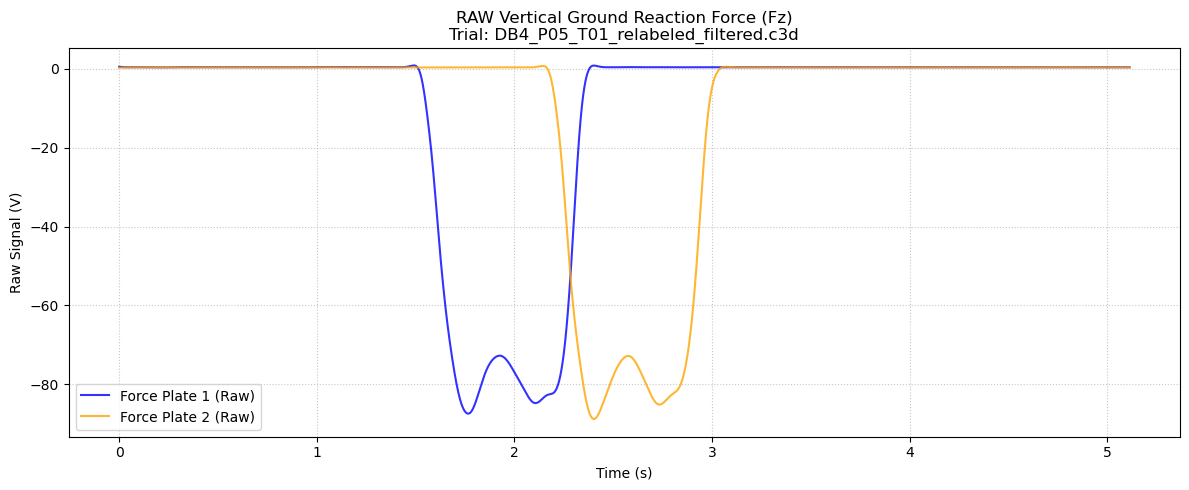

In [11]:
sample_idx = 0
sample_name = c3d_files[sample_idx]
c_path = os.path.join(c3d_folder, sample_name)

reader = ezc3d.c3d(c_path)

p1_raw = reader['data']['analogs'][0, 0:6, :]
p2_raw = reader['data']['analogs'][0, 6:12, :]

# Extract ONLY the vertical component (Fz is index 2 for both slices)
vGRF1_raw = p1_raw[2, :]
vGRF2_raw = p2_raw[2, :]

# Check the raw units to label the Y-axis correctly (V or N)
raw_units = reader['parameters']['ANALOG']['UNITS']['value'][2]

time = np.arange(len(vGRF1_raw)) / base_analog_rate
plt.figure(figsize=(12, 5))

plt.plot(time, vGRF1_raw, label='Force Plate 1 (Raw)', color='blue', alpha=0.8)
plt.plot(time, vGRF2_raw, label='Force Plate 2 (Raw)', color='orange', alpha=0.8)

plt.title(f"RAW Vertical Ground Reaction Force (Fz)\nTrial: {sample_name}")
plt.xlabel("Time (s)")
plt.ylabel(f"Raw Signal ({raw_units})") # Dynamically updates to Volts or Newtons
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### Conversion V to N and Inversion Functions

In [12]:
def convert_VtoN(c3d_handle, plate_idx, start_ch, num_channels=6):
    """
    This converts raw Voltage signals into calibrated Newtons (Forces) 
    and Newton-meters (Moments) by applying the 6x6 calibration matrix 
    to raw analog voltage data.

    Parameters:
    - c3d_handle: The loaded ezc3d file object.
    - plate_idx: 0 for Plate 1, 1 for Plate 2.
    - start_ch: Starting channel where forces are stored
    - num_channels: Standard is 6 channels per plate (Fx, Fy, Fz, Mx, My, Mz).
    """
    # 1. Get the Matrix (6x6) for the specific plate
    cal_matrix = c3d_handle['parameters']['FORCE_PLATFORM']['CAL_MATRIX']['value'][:, :, plate_idx]

    # 2. Get the analog indices for this specific plate
    end_ch = start_ch + num_channels
    raw_volts = c3d_handle['data']['analogs'][0, start_ch:end_ch, :]

    # 3. Matrix Multiplication: [6x6] @ [6xN]
    # Result: [Fx, Fy, Fz, Mx, My, Mz]
    return np.dot(cal_matrix, raw_volts)

In [13]:
def apply_inversion(forces, vert_idx=2, ap_idx=1, ml_idx=0):
    """
    Ensures the Force Plate coordinate system matches the physical world.
    1. Checks Vertical (Z): Up must be positive.
    2. Checks Anterior-Posterior (AP): Braking (negative) must precede Propulsion (positive).

    Parameters:
    - forces: 6xN or 3xN numpy array.
    - vert_idx, ap_idx, ml_idx: Indices for Vertical, Forward, and Side-to-Side axes.
    """
    vert_inverted = False
    ap_inverted = False

    # --- STEP 1: VERTICAL CHECK ---
    # If the deepest negative is larger than the highest positive, it's upside down
    if np.abs(np.min(forces[vert_idx])) > np.abs(np.max(forces[vert_idx])):
        forces = forces * -1  # Invert ALL axes to fix the upside-down plate
        vert_inverted = True

    # --- STEP 2: ANTERIOR-POSTERIOR (FORWARD) CHECK ---
    # Find timing of the braking peak (min) and propulsion peak (max)
    idx_min = np.argmin(forces[ap_idx]) 
    idx_max = np.argmax(forces[ap_idx])
    # If propulsion happens BEFORE braking, the plate is rotated 180 degrees
    if idx_max < idx_min:
        forces[ap_idx] = forces[ap_idx] * -1
        #forces[ml_idx] = forces[ml_idx] * -1 # If rotated 180, ML is backwards too!
        ap_inverted = True

        """Moments are not flipped, YET"""
        # Note: If you are extracting Moments (Mx, My, Mz), a 180-degree rotation 
        # also flips the moments. If forces has 6 rows, flip the moments too:
        #if forces.shape[0] >= 6:
            #forces[ap_idx + 3] = forces[ap_idx + 3] * -1
            #forces[ml_idx + 3] = forces[ml_idx + 3] * -1

    return forces, vert_inverted, ap_inverted

### GRF Inversion

DB3 has ap_idx in 0; all the other in 1

In [14]:
GRF_data = {}
total_inversions = 0

for c3d_name in c3d_files:
    reader = ezc3d.c3d(os.path.join(c3d_folder, c3d_name))

    # --- DYNAMIC INDEX TRACKING ---
    # Extract labels, clean up spaces, and convert to uppercase for safe matching
    #analog_labels = [label.strip() for label in reader['parameters']['ANALOG']['LABELS']['value']]
    analog_labels = reader['parameters']['ANALOG']['LABELS']['value']
    #print(f"{analog_labels}")

    # Find the exact starting index for each force plate (where Fx begins)
    # This looks for the label that, once stripped of all invisible characters, matches 'Fx1'
    ##p1_start = analog_labels.index('Fx1')
    ##p2_start = analog_labels.index('Fx2')

    p1_start = next(i for i, label in enumerate(analog_labels) if label.endswith('Fx1'))
    p2_start = next(i for i, label in enumerate(analog_labels) if label.endswith('Fx2'))

    # Dynamically check units of the first vertical force channel (Fz1 is at index + 2)
    analog_units = reader['parameters']['ANALOG']['UNITS']['value'][p1_start + 2]
    
    # 1. Check units and Extract/Calibrate Data
    if 'V' == analog_units.upper():
        # DATA IS RAW VOLTAGE: Apply the conversion to Newtons
        p1_final = convert_VtoN(reader, plate_idx=0, start_ch=p1_start) # Force plate 1
        p2_final = convert_VtoN(reader, plate_idx=1, start_ch=p2_start) # Force plate 2
        print(f"  > [{c3d_name}]: units in V. Applied calibration matrix.")
    else:
        # DATA IS ALREADY IN NEWTONS: Extract directly
        p1_final = reader['data']['analogs'][0, p1_start:p1_start+6, :]
        p2_final = reader['data']['analogs'][0, p1_start:p2_start+6, :]

    # 2. Inversion - Apply all spatial corrections (assuming Z=2, Y=1, X=0)
    p1_corr, v_inv1, ap_inv1 = apply_inversion(p1_final, vert_idx=2, ap_idx=1, ml_idx=0)
    p2_corr, v_inv2, ap_inv2 = apply_inversion(p2_final, vert_idx=2, ap_idx=1, ml_idx=0)

    # Track how many plates required coordinate flipping
    if v_inv1 or v_inv2:
        total_inversions += 1

    # 3. Store the fully corrected 6-component arra
    GRF_data[c3d_name] = (p1_corr, p2_corr)

print(f"✅ Processed {len(GRF_data)} trials. Total plates inverted: {total_inversions}")

  > [DB4_P05_T01_relabeled_filtered.c3d]: units in V. Applied calibration matrix.
  > [DB4_P05_T02_relabeled_filtered.c3d]: units in V. Applied calibration matrix.
  > [DB4_P05_T04_relabeled_filtered.c3d]: units in V. Applied calibration matrix.
✅ Processed 3 trials. Total plates inverted: 3


### 3. GRF Extraction (If needed: Conversion V to N / Inversion)

### Visualizing Vertical GRF
This section provides the visualization of the vertical GRF from both force plates for only one file in the dataset to verify the extraction and inversion correction. A reference line is plotted at 20N to visually verify the threshold  for subsequent gait event detection (Heel Strike and Toe-Off).

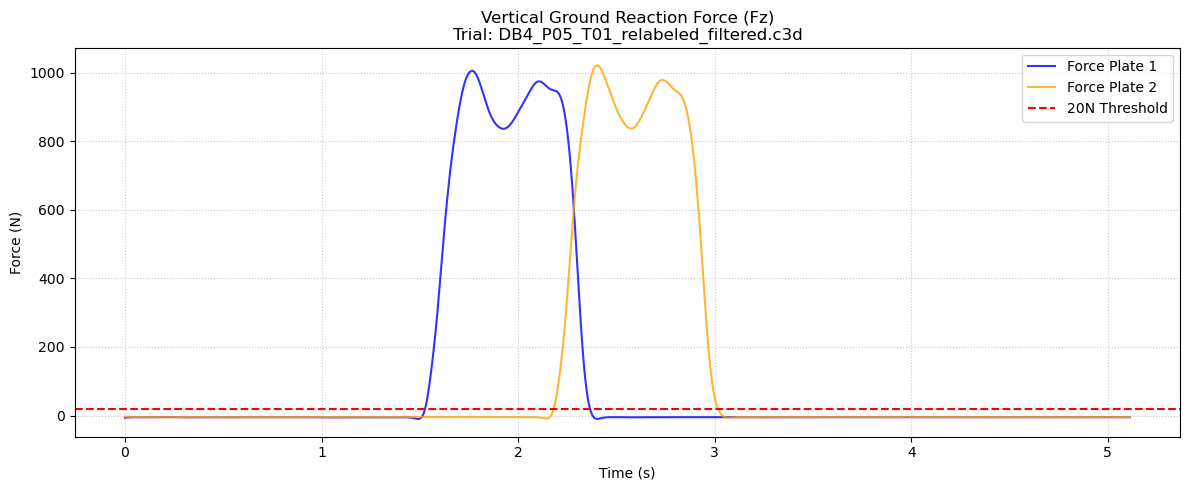

In [15]:
sample_idx = 0
sample_name = c3d_files[sample_idx]

# Retrieve the full 6-component GRF data for both plates
p1_data, p2_data = GRF_data[sample_name]

# Extract ONLY the vertical component (Fz is index 2) for plotting
vGRF1_plot = p1_data[2, :]
vGRF2_plot = p2_data[2, :]

time = np.arange(len(vGRF1_plot)) / base_analog_rate

plt.figure(figsize=(12, 5))

plt.plot(time, vGRF1_plot, label='Force Plate 1', color='blue', alpha=0.8)
plt.plot(time, vGRF2_plot, label='Force Plate 2', color='orange', alpha=0.8)
plt.axhline(y=20, color='red', linestyle='--', label='20N Threshold') 

# Formatting
plt.title(f"Vertical Ground Reaction Force (Fz)\nTrial: {sample_name}")
plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### Event Detection & Leg Identification Functions

In [16]:
def detect_raw_events(force_data, threshold=20):
    """
    Identifies all frames where a foot makes contact (Heel Strike) or 
    leaves the ground (Toe-Off) based on a vertical force threshold.

    Parameters:
    - force_data: 1D numpy array of vertical GRF (usually Fz).
    - threshold: The force value (in Newtons) to trigger an event.

    Returns:
    - hs_frames: Array of indices where the foot landed.
    - to_frames: Array of indices where the foot lifted.
    """
    # 1. Binarize the signal based on the threshold: 0 for no contact, 1 for contact
    contact = (force_data > threshold).astype(int)

    # 2. Find the differences between adjacent frames
    #  1 - 0 =  1 (Heel Strike: transition to contact)
    #  0 - 1 = -1 (Toe-Off: transition to no contact)
    transitions = np.diff(contact)

    # 3. Extract indices and adjust for the shift caused by np.diff
    hs_frames = np.where(transitions == 1)[0] + 1
    to_frames = np.where(transitions == -1)[0] + 1

    return hs_frames, to_frames

In [17]:
def filter_gait_events(hs_raw, to_raw, sampling_rate):
    """
    Validates and pairs raw Heel Strikes (HS) and Toe-Offs (TO) by ensuring 
    the duration of the stance phase falls within a realistic physiological window.
    This filters out brief signal spikes, sensor artifacts, or incomplete 
    foot contacts that do not constitute a full gait stance phase.

    Parameters:
    - hs_raw: Array of raw heel strike frame indices.
    - to_raw: Array of raw toe-off frame indices.
    - sampling_rate: The sampling frequency (Hz) of the force data.

    Returns:
    - paired_hs: Cleaned numpy array of validated heel strike frames.
    - paired_to: Cleaned numpy array of validated toe-off frames.
    """
    # Broad window: 0.5s to 1.0s captures standard overground walking stance phases
    min_stance, max_stance = 0.5, 1.0  # MODIFY if needed

    paired_hs, paired_to = [], []

    # Loop through each raw heel strike and find its matching toe-off
    for hs in hs_raw:
        # Find all toe-offs that happen chronologically after this heel strike
        possible_tos = to_raw[to_raw > hs]

        if len(possible_tos) > 0:
            # The first toe-off after the heel strike is the end of this stance phase
            to = possible_tos[0]
            stance_duration = (to - hs) / sampling_rate

            # Validate whether the stance duration makes sense for a human step
            if min_stance < stance_duration < max_stance:
                paired_hs.append(hs)
                paired_to.append(to)

    return np.array(paired_hs), np.array(paired_to)

In [18]:
def detect_hs2_by_ref(marker_z, to_frame, ref_height, buffer=2.0):
    """
    Detects the second Heel Strike (HS2) of a gait cycle using kinematic marker data.

    It starts searching after the Toe-Off frame (during the swing phase) and looks 
    for the first frame where the heel marker's vertical height drops back down 
    to the baseline reference height (from HS1), while maintaining a downward velocity.

    Parameters:
    - marker_z: 1D numpy array representing the Z (vertical) coordinate of the heel marker.
    - to_frame: The frame index of Toe-Off (converted to the marker sampling rate).
    - ref_height: The Z-coordinate height of the heel marker at the initial HS1.
    - buffer: An allowable tolerance (in millimeters) above the reference height to account 
              for tissue deformation or shoe scuffing.

    Returns:
    - hs2_frame: The absolute frame index of the second Heel Strike, or None if not found.
    """
    # Start looking 10 frames after Toe-Off to avoid immediate post-lift-off noise
    search_start = to_frame + 10
    swing_data = marker_z[search_start:]

    # If the remaining trial data is too short, we cannot find a full gait cycle
    if len(swing_data) < 5: 
        return None

    # Loop through the swing phase data to find the landing event
    for i in range(1, len(swing_data)):
        current_height = swing_data[i]

        # Calculate vertical velocity (Difference between current frame and previous frame)
        # A negative value means the foot is actively moving downward toward the floor
        velocity = swing_data[i] - swing_data[i-1]

        # Condition: Height is close to the floor baseline AND the foot is moving downward
        if current_height <= (ref_height + buffer) and velocity < 0:
            return search_start + i

    return None

In [19]:
def identify_plate_foot(m_data, hs_analog, frame_ratio, l_hee_idx, r_hee_idx):
    """
    Identifies whether the left or right foot caused a force plate trigger.
    It looks at a 10-frame window starting at the heel strike frame and 
    compares the average vertical (Z) height of the left and right heel markers.

    Returns:
    - 'left' or 'right' (string)
    - the specific marker index corresponding to that foot (int)
    """
    # Convert analog frame to camera frame
    hs_cam = int(np.round(hs_analog / frame_ratio))
    window_end_cam = min(hs_cam + 10, m_data.shape[2])

    # Calculate mean Z-height over the window
    mean_z_l = np.mean(m_data[2, l_hee_idx, hs_cam:window_end_cam])
    mean_z_r = np.mean(m_data[2, r_hee_idx, hs_cam:window_end_cam])

    if mean_z_l < mean_z_r:
        return 'left', l_hee_idx
    else:
        return 'right', r_hee_idx

### 4. Dynamic Gait Event Segmentation & Leg Identification

REVISAR base_analog_rate

In [20]:
gait_events = {}      # Format: { c3d_name: { 'leading_side': str, 'foot_1': tuple, 'foot_2': tuple } }
threshold_value = 10  # MODIFY if needed
frame_ratio = base_analog_rate / base_point_rate

print(f"Processing single strides... Camera: {base_point_rate}Hz | Analog: {base_analog_rate}Hz")
print(f"Using {threshold_value}N threshold for contact windows.\n")

for c3d_name in c3d_files:
    # 1. Extract corrected vertical GRFs (Stored from previous blocks)
    p1_corr, p2_corr = GRF_data[c3d_name]
    vGRF1, vGRF2 = p1_corr[2, :], p2_corr[2, :]

    # 2. Detect and filter force plate events per plate
    h1_raw, t1_raw = detect_raw_events(vGRF1, threshold=threshold_value)
    h2_raw, t2_raw = detect_raw_events(vGRF2, threshold=threshold_value)
    hs_list_p1, to_list_p1 = filter_gait_events(h1_raw, t1_raw, base_analog_rate)
    hs_list_p2, to_list_p2 = filter_gait_events(h2_raw, t2_raw, base_analog_rate)

    # Skip trial if either plate failed to catch a clean, valid foot strike
    if len(hs_list_p1) == 0 or len(hs_list_p2) == 0:
        print(f"⚠️ Warning: Skipping {c3d_name} due to missing valid steps on one or both plates.")
        continue

    # Extract the FIRST valid step from each plate
    p1_hs1_a, p1_to_a = hs_list_p1[0], to_list_p1[0]
    p2_hs1_a, p2_to_a = hs_list_p2[0], to_list_p2[0]

    # 3. Load Kinematic Marker Data
    df_c3d = ezc3d.c3d(os.path.join(c3d_folder, c3d_name))
    m_data = df_c3d['data']['points'][:3, :, :] 
    labels = df_c3d['parameters']['POINT']['LABELS']['value']
    l_hee_idx, r_hee_idx = labels.index('LHEE'), labels.index('RHEE')

    # 4. IDENTIFY ANATOMY: Which foot is on Plate 1? (Using 10-frame average window)
    p1_side, p1_hee_idx = identify_plate_foot(m_data, p1_hs1_a, frame_ratio, l_hee_idx, r_hee_idx)

    # By default, Plate 2 must be the opposite foot
    if p1_side == 'left':
        p2_side, p2_hee_idx = 'right', r_hee_idx
    else:
        p2_side, p2_hee_idx = 'left', l_hee_idx

    # 5. IDENTIFY CHRONOLOGY: Which plate triggered first?
    if p1_hs1_a < p2_hs1_a:
        leading_side = p1_side
        # Plate 1 is Foot 1 (Leading)
        f1_hs1_a, f1_to_a, f1_hee_idx = p1_hs1_a, p1_to_a, p1_hee_idx
        # Plate 2 is Foot 2 (Following)
        f2_hs1_a, f2_to_a, f2_hee_idx = p2_hs1_a, p2_to_a, p2_hee_idx
    else:
        leading_side = p2_side
        # Plate 2 is Foot 1 (Leading)
        f1_hs1_a, f1_to_a, f1_hee_idx = p2_hs1_a, p2_to_a, p2_hee_idx
        # Plate 1 is Foot 2 (Following)
        f2_hs1_a, f2_to_a, f2_hee_idx = p1_hs1_a, p1_to_a, p1_hee_idx

    # 6. KINEMATIC SWING TRACKING: Find HS2 for Foot 1 and Foot 2 using markers
    # Foot 1 Kinematics
    f1_hs1_p = int(np.round(f1_hs1_a / frame_ratio))
    f1_to_p = int(np.round(f1_to_a / frame_ratio))
    ref_z_f1 = m_data[2, f1_hee_idx, f1_hs1_p]
    f1_hs2_p = detect_hs2_by_ref(m_data[2, f1_hee_idx, :], f1_to_p, ref_z_f1)
    f1_hs2_a = int(f1_hs2_p * frame_ratio) if f1_hs2_p else None

    # Foot 2 Kinematics
    f2_hs1_p = int(np.round(f2_hs1_a / frame_ratio))
    f2_to_p = int(np.round(f2_to_a / frame_ratio))
    ref_z_f2 = m_data[2, f2_hee_idx, f2_hs1_p]
    f2_hs2_p = detect_hs2_by_ref(m_data[2, f2_hee_idx, :], f2_to_p, ref_z_f2)
    f2_hs2_a = int(f2_hs2_p * frame_ratio) if f2_hs2_p else None

    # 7. STORE THE STRUCTURE
    if p1_hs1_a < p2_hs1_a:
        f1_plate_idx = 0  # Plate 1
        f2_plate_idx = 1  # Plate 2
    else:
        f1_plate_idx = 1  # Plate 2
        f2_plate_idx = 0  # Plate 1

    gait_events[c3d_name] = {
        'leading_side': leading_side,
        'f1_plate_idx': f1_plate_idx,  # Saved hardware link
        'f2_plate_idx': f2_plate_idx,  # Saved hardware link
        'foot_1': (f1_hs1_a, f1_hs2_a),
        'foot_2': (f2_hs1_a, f2_hs2_a)
    }

# --- SIMPLIFIED SUMMARY TABLE ---
print(f"\n{'Trial Name':<35} | {'Lead Side':<12} | {'Foot 1 (Leading)':<18} | {'Foot 2 (Following)':<18}")
print("-" * 90)
for name, data in gait_events.items():
    lead = data['leading_side'].upper()
    f1_status = "Complete" if data['foot_1'][1] else "Partial"
    f2_status = "Complete" if data['foot_2'][1] else "Partial"
    print(f"{name:<35} | {lead:<12} | {f1_status:<18} | {f2_status:<18}")

Processing single strides... Camera: 250.0Hz | Analog: 2000.0Hz
Using 10N threshold for contact windows.


Trial Name                          | Lead Side    | Foot 1 (Leading)   | Foot 2 (Following)
------------------------------------------------------------------------------------------
DB4_P05_T01_relabeled_filtered.c3d  | RIGHT        | Complete           | Complete          
DB4_P05_T02_relabeled_filtered.c3d  | LEFT         | Complete           | Complete          
DB4_P05_T04_relabeled_filtered.c3d  | LEFT         | Complete           | Complete          


### Visualizing of Gait Events

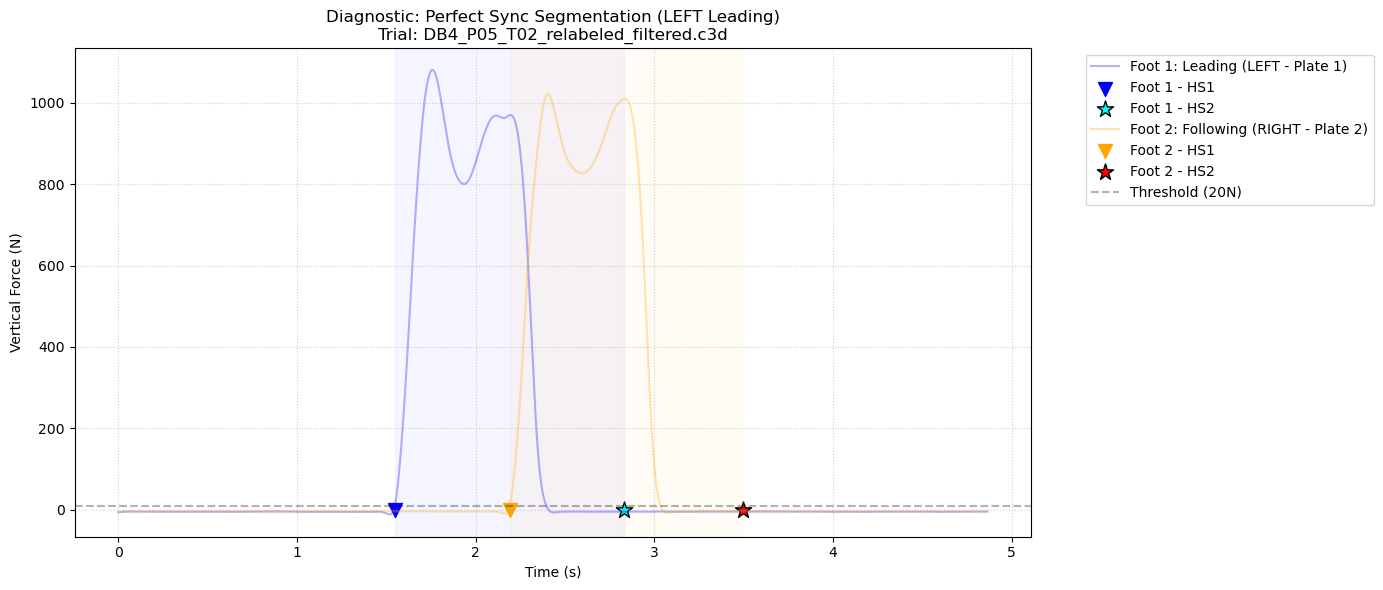

In [21]:
sample_idx = 1
sample_name = c3d_files[sample_idx]

# Extract the raw plate arrays from your original storage tuple
plates_tuple = GRF_data[sample_name] 

stride = gait_events[sample_name]
leading_foot = stride['leading_side']
f1_hs1, f1_hs2 = stride['foot_1']
f2_hs1, f2_hs2 = stride['foot_2']

# Direct hardware lookup using our new keys
f1_raw_array = plates_tuple[stride['f1_plate_idx']]
f2_raw_array = plates_tuple[stride['f2_plate_idx']]

# Extract the vertical force component (Z-axis is index 2)
f1_signal = f1_raw_array[2, :]
f2_signal = f2_raw_array[2, :]

# Set labels dynamically based on the true configuration
f1_label = f"Foot 1: Leading ({leading_foot.upper()} - Plate {stride['f1_plate_idx'] + 1})"
following_foot = "right" if leading_foot == "left" else "left"
f2_label = f"Foot 2: Following ({following_foot.upper()} - Plate {stride['f2_plate_idx'] + 1})"

time_vec = np.arange(len(f1_signal)) / base_analog_rate

plt.figure(figsize=(14, 6))

# --- PLOT FOOT 1 (LEADING - ALWAYS BLUE) ---
plt.plot(time_vec, f1_signal, color='blue', alpha=0.3, label=f1_label)
if f1_hs1 is not None:
    plt.scatter(f1_hs1/base_analog_rate, 0, color='blue', marker='v', s=100, label='Foot 1 - HS1')
if f1_hs2 is not None:
    plt.scatter(f1_hs2/base_analog_rate, 0, color='cyan', marker='*', s=150, edgecolors='black', label='Foot 1 - HS2')
    plt.axvspan(f1_hs1/base_analog_rate, f1_hs2/base_analog_rate, color='blue', alpha=0.04)

# --- PLOT FOOT 2 (FOLLOWING - ALWAYS ORANGE) ---
plt.plot(time_vec, f2_signal, color='orange', alpha=0.3, label=f2_label)
if f2_hs1 is not None:
    plt.scatter(f2_hs1/base_analog_rate, 0, color='orange', marker='v', s=100, label='Foot 2 - HS1')
if f2_hs2 is not None:
    plt.scatter(f2_hs2/base_analog_rate, 0, color='red', marker='*', s=150, edgecolors='black', label='Foot 2 - HS2')
    plt.axvspan(f2_hs1/base_analog_rate, f2_hs2/base_analog_rate, color='orange', alpha=0.04)

# Formatting
plt.axhline(y=threshold_value, color='black', linestyle='--', alpha=0.3, label='Threshold (20N)')
plt.title(f"Diagnostic: Perfect Sync Segmentation ({leading_foot.upper()} Leading)\nTrial: {sample_name}")
plt.xlabel("Time (s)")
plt.ylabel("Vertical Force (N)")
plt.grid(True, linestyle=':', alpha=0.6)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Time-Normalization Functions

In [22]:
def interp_101(data, original_len):
    """
    Interpolates 1D, 2D, or 3D time-series data to exactly 101 points, 
    representing 0% to 100% of a normalized gait cycle.
    This function safely handles multi-dimensional arrays (like 3D marker 
    trajectories or 2D force plate matrices) by flattening the spatial 
    dimensions, applying standard 1D linear interpolation across the time 
    domain, and then restructuring the array back to its original spatial shape.

    Parameters:
    - data: A numpy array (1D, 2D, or 3D) where the last dimension is Time.
            (e.g., [3 x Markers x Frames] for kinematics or [6 x Frames] for GRF)
    - original_len: int. The actual number of recorded frames in the raw data slice.

    Returns:
    - time_normalized_data: A numpy array matching the input's spatial dimensions, 
                            but with the final time dimension normalized to 101.
    """

    if original_len < 2: return data 
    
    old_x = np.linspace(0, 100, original_len)
    new_x = np.linspace(0, 100, 101)

    if data.ndim == 1:
        return np.interp(new_x, old_x, data)

    # For multi-dim (Markers/IK/ID/GRF): reshape to flatten spatial dimensions, interpolate, & restore.
    original_shape = data.shape
    flat_data = data.reshape(-1, original_len)
    interp_flat = np.array([np.interp(new_x, old_x, row) for row in flat_data])

    # Restore to (D1, D2, 101)
    return interp_flat.reshape(original_shape[:-1] + (101,))

### 5. Time-Normalization to 101 Points (Batch Processing)
This section interpolates both the **Kinetics**, **Kinematics**, **IK**, and **ID** to a standard 101-point vector, representing 0% to 100% of the gait cycle.

In [23]:
time_normalized_data = {} 
frame_ratio = base_analog_rate / base_point_rate

for i, c3d_name in enumerate(c3d_files):
    # 1. Load Data Streams
    c = ezc3d.c3d(os.path.join(c3d_folder, c3d_name))
    m = c['data']['points'][:3, :, :]
    
    # Extract the full 6-component arrays (Fx, Fy, Fz, Mx, My, Mz) for both plates
    p1_corr, p2_corr = GRF_data[c3d_name]
    plates = (p1_corr, p2_corr)
    
    ik = pd.read_csv(os.path.join(ik_folder, ik_files[i]), sep='\t', skiprows=10).values.T
    id_ = pd.read_csv(os.path.join(id_folder, id_files[i]), sep='\t', skiprows=10).values.T

    ev = gait_events[c3d_name]
    cycles = {k: [] for k in ['kinematics', 'GRF', 'ik', 'id', 'side_label', 'foot_role']}

    # 2. Resolve Anatomy to Side Labels (0 = Left, 1 = Right)
    lead_side = ev['leading_side']
    if lead_side == 'left':
        f1_anatomy_idx = 0  # Foot 1 is Left
        f2_anatomy_idx = 1  # Foot 2 is Right
    else:
        f1_anatomy_idx = 1  # Foot 1 is Right
        f2_anatomy_idx = 0  # Foot 2 is Left

    # 3. Setup the Iteration Sequence using the hardware indices saved earlier
    feet_to_process = [
        ('foot_1', ev['foot_1'], f1_anatomy_idx, plates[ev['f1_plate_idx']]),
        ('foot_2', ev['foot_2'], f2_anatomy_idx, plates[ev['f2_plate_idx']])
    ]

    # 4. Process Both Roles
    for role_name, (hs1_a, hs2_a), anatomy_idx, grf_signal in feet_to_process:
        # Skip incomplete strides ("Partial" or "None" filtering)
        if hs2_a is None: 
            continue

        # Define cycle window bounds
        s_a, e_a = int(hs1_a), int(hs2_a) 
        s_p, e_p = int(np.round(s_a / frame_ratio)), int(np.round(e_a / frame_ratio)) 

        # Safety Cap: Ensure indices don't exceed array boundaries 
        e_p = min(e_p, m.shape[2], ik.shape[1], id_.shape[1])
        e_a = min(e_a, grf_signal.shape[1])

        # Interpolate and store
        cycles['kinematics'].append(interp_101(m[:, :, s_p:e_p], e_p - s_p))
        cycles['GRF'].append(interp_101(grf_signal[:, s_a:e_a], e_a - s_a))
        cycles['ik'].append(interp_101(ik[:, s_p:e_p], e_p - s_p))
        cycles['id'].append(interp_101(id_[:, s_p:e_p], e_p - s_p))
        
        cycles['side_label'].append(anatomy_idx)
        cycles['foot_role'].append(role_name)

    # 5. Store in master dictionary if at least one complete cycle was found
    if len(cycles['side_label']) > 0:
        time_normalized_data[c3d_name] = {k: np.array(v) for k, v in cycles.items() if k != 'foot_role'}
        # Keep string descriptors separate from numpy arrays
        time_normalized_data[c3d_name]['foot_role'] = cycles['foot_role']

print(f"✅ Total completed gait cycles normalized: {sum(len(v['side_label']) for v in time_normalized_data.values())}")

✅ Total completed gait cycles normalized: 6


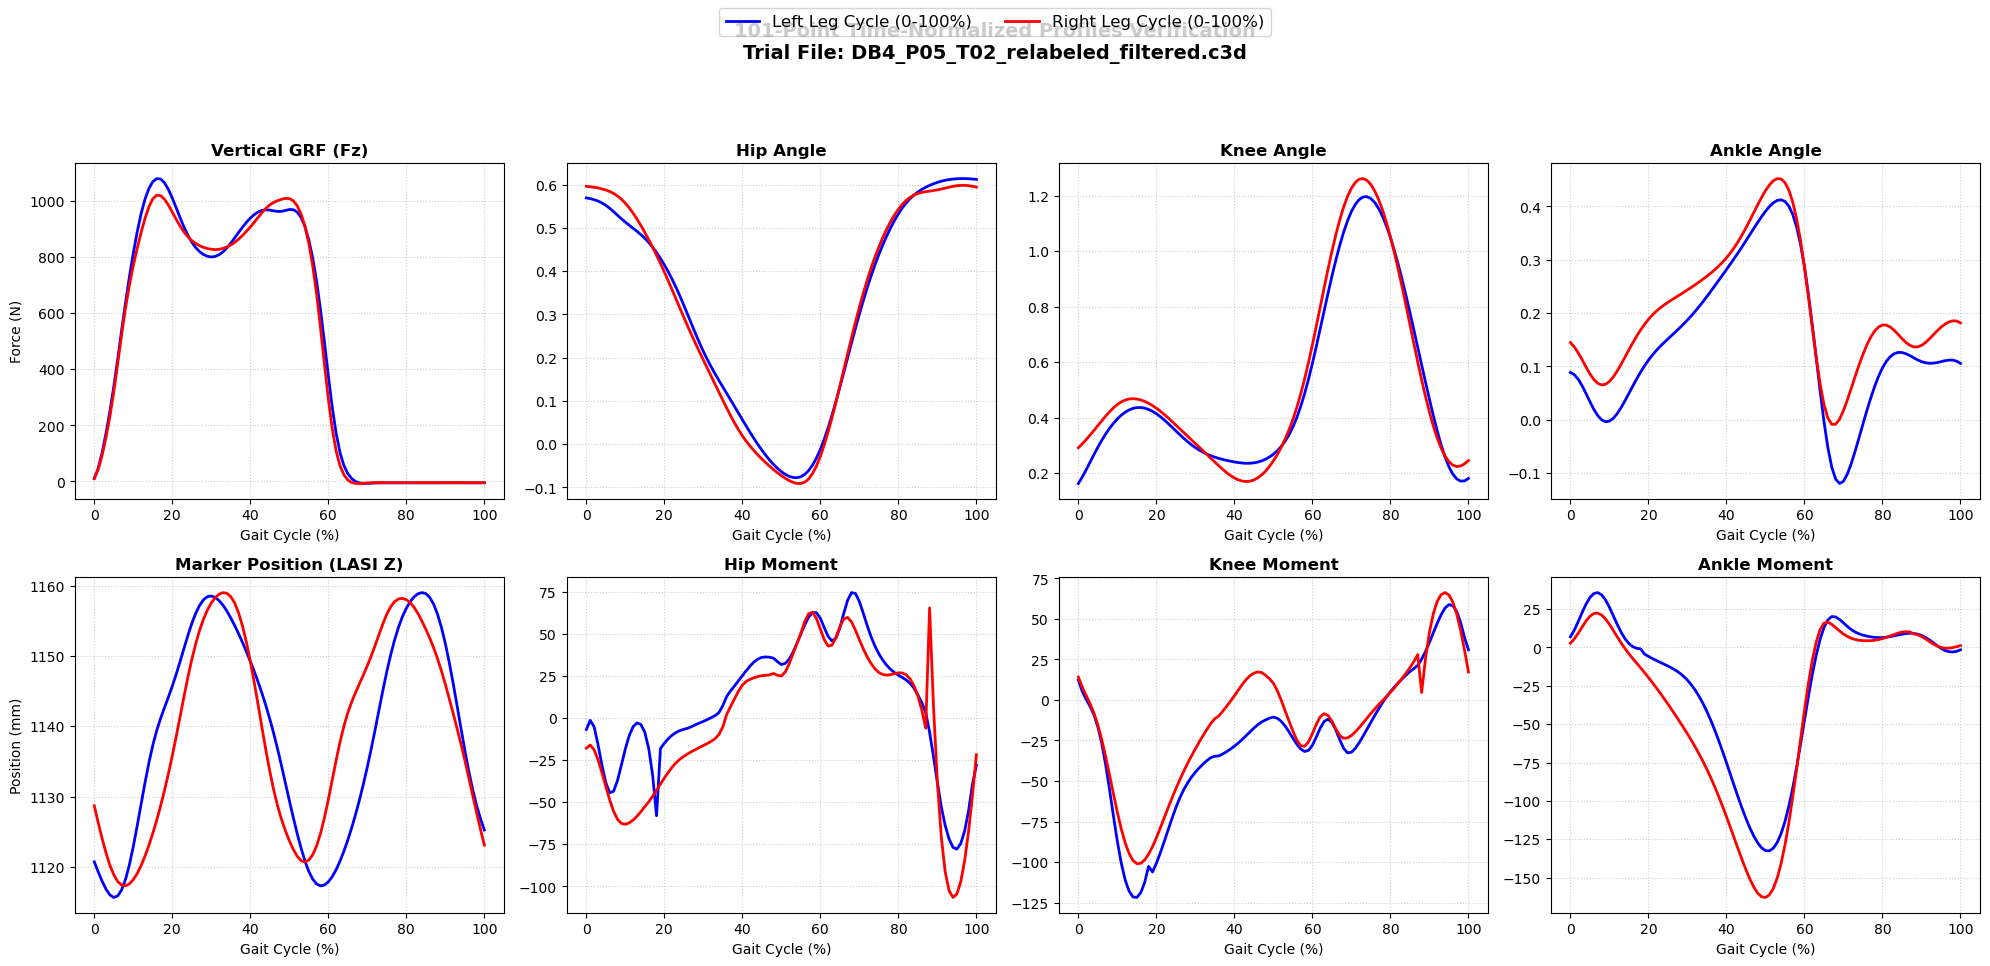

In [24]:
## ENHANCED VISUALIZATION BLOCK: 101-Point Normalized Stride Verification
sample_idx = 1  # 0 for T01, or change to 2 for T04 to see how it automatically drops the partial leg
sample_file = c3d_files[sample_idx] 

# Pull the compiled 101-point matrix for this trial
data = time_normalized_data[sample_file]
normalized_time = np.linspace(0, 100, 101)

# 1. Read headers directly from the corresponding OpenSim CSV files
ik_headers = pd.read_csv(os.path.join(ik_folder, ik_files[sample_idx]), sep='\t', skiprows=10).columns.tolist()
id_headers = pd.read_csv(os.path.join(id_folder, id_files[sample_idx]), sep='\t', skiprows=10).columns.tolist()

# 2. Extract C3D Marker labels to locate the LASI index
df_c3d = ezc3d.c3d(os.path.join(c3d_folder, sample_file))
c3d_labels = df_c3d['parameters']['POINT']['LABELS']['value']
lasi_m_idx = c3d_labels.index('LASI') if 'LASI' in c3d_labels else 0

def get_col_idx(headers, joint, side_idx):
    """Finds the column index matching the joint name and side suffix (_l or _r)."""
    side_pref = '_l' if side_idx == 0 else '_r'
    try:
        return [i for i, h in enumerate(headers) if joint in h and side_pref in h][0]
    except IndexError:
        raise ValueError(f"Could not find header combining joint '{joint}' and side '{side_pref}'")

# --- PLOTTING CONFIGURATION ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
joints = ['hip_flexion', 'knee_angle', 'ankle_angle']
titles = ['Vertical GRF (Fz)', 'Hip Angle', 'Knee Angle', 'Ankle Angle', 
          'Marker Position (LASI Z)', 'Hip Moment', 'Knee Moment', 'Ankle Moment']

sides = data['side_label']  # Array of 0s (Left) and 1s (Right)

# Iterate through each normalized leg cycle stored inside this file
for s_idx in range(len(sides)):
    current_side = sides[s_idx]
    color = 'blue' if current_side == 0 else 'red'
    label_text = 'Left Leg' if current_side == 0 else 'Right Leg'
    
    # ----------------------------------------------------
    # ROW 1, COL 0: Vertical Ground Reaction Force (Fz)
    # The normalized GRF array is (6 components x 101 frames). Vertical Force is index 2.
    # ----------------------------------------------------
    axes[0, 0].plot(normalized_time, data['GRF'][s_idx, 2, :], color=color, linewidth=2, label=label_text)

    # ----------------------------------------------------
    # ROW 2, COL 0: Kinematics (LASI Z Trajectory)
    # Array shape is: (3 coordinates [X,Y,Z] x Markers x 101 frames). Z is index 2.
    # ----------------------------------------------------
    axes[1, 0].plot(normalized_time, data['kinematics'][s_idx, 2, lasi_m_idx, :], color=color, linewidth=2)

    # ----------------------------------------------------
    # PLOT OPEN SIM JOINTS: IK (Angles) and ID (Moments)
    # ----------------------------------------------------
    for j_idx, joint in enumerate(joints):
        ik_c = get_col_idx(ik_headers, joint, current_side)
        id_c = get_col_idx(id_headers, joint, current_side)

        # Plot Joint Angles (IK row 0, columns 1-3)
        axes[0, j_idx + 1].plot(normalized_time, data['ik'][s_idx, ik_c, :], color=color, linewidth=2)
        
        # Plot Joint Moments (ID row 1, columns 1-3)
        axes[1, j_idx + 1].plot(normalized_time, data['id'][s_idx, id_c, :], color=color, linewidth=2)

# Global Figure Formatting
for i, ax in enumerate(axes.flat):
    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.set_xlabel("Gait Cycle (%)")
    ax.grid(True, linestyle=':', alpha=0.6)
    if i == 0: ax.set_ylabel("Force (N)")
    if i == 4: ax.set_ylabel("Position (mm)")

# Add clear global custom legend
legend_elements = [Line2D([0], [0], color='blue', lw=2, label='Left Leg Cycle (0-100%)'),
                   Line2D([0], [0], color='red', lw=2, label='Right Leg Cycle (0-100%)')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12)

fig.suptitle(f"101-Point Time-Normalized Profiles Verification\nTrial File: {sample_file}", 
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

### ⬆️ Version incorrecta

In [25]:
## UPDATED TIME-NORMALIZATION BLOCK: Real-World Synchronized Timeline
time_normalized_data = {} 
frame_ratio = base_analog_rate / base_point_rate

for i, c3d_name in enumerate(c3d_files):
    c = ezc3d.c3d(os.path.join(c3d_folder, c3d_name))
    m = c['data']['points'][:3, :, :]
    
    p1_corr, p2_corr = GRF_data[c3d_name]
    plates = (p1_corr, p2_corr)
    
    ik = pd.read_csv(os.path.join(ik_folder, ik_files[i]), sep='\t', skiprows=10).values.T
    id_ = pd.read_csv(os.path.join(id_folder, id_files[i]), sep='\t', skiprows=10).values.T

    ev = gait_events[c3d_name]
    
    # CRITICAL CHANGE: Both feet will now use the Leading Foot's (foot_1) timeline bounds
    f1_hs1_a, f1_hs2_a = ev['foot_1']
    
    # Skip trial entirely if the leading foot cannot even complete its cycle
    if f1_hs2_a is None:
        continue

    # Define the Single Master Window based on the Leader
    s_a, e_a = int(f1_hs1_a), int(f1_hs2_a) 
    s_p, e_p = int(np.round(s_a / frame_ratio)), int(np.round(e_a / frame_ratio)) 

    # Safety Cap boundaries
    e_p = min(e_p, m.shape[2], ik.shape[1], id_.shape[1])
    e_a = min(e_a, p1_corr.shape[1], p2_corr.shape[1])

    # Extract the routed hardware signals
    f1_grf_raw = plates[ev['f1_plate_idx']]
    f2_grf_raw = plates[ev['f2_plate_idx']]

    # Resolve Side Labels (0 = Left, 1 = Right)
    lead_side = ev['leading_side']
    f1_side_idx = 0 if lead_side == 'left' else 1
    f2_side_idx = 1 if lead_side == 'left' else 0


    # Interpolate everything using the exact same master slice window
    trial_cycles = {
        # Kinematics/IK/ID capture the whole body, so we just pull the master window slice once
        'kinematics': interp_101(m[:, :, s_p:e_p], e_p - s_p),
        'ik': interp_101(ik[:, s_p:e_p], e_p - s_p),
        'id': interp_101(id_[:, s_p:e_p], e_p - s_p),
        # Pull the forces for both plates during this identical master window
        'GRF_f1': interp_101(f1_grf_raw[:, s_a:e_a], e_a - s_a),
        'GRF_f2': interp_101(f2_grf_raw[:, s_a:e_a], e_a - s_a),
        # Meta trackers
        'side_labels': [f1_side_idx, f2_side_idx],
        
        # Reference labels 
        'marker_labels': c3d_labels,       # The string list of marker names (from C3D)
        'grf_labels': ['Fx', 'Fy', 'Fz', 'Mx', 'My', 'Mz'], # Hardcoded components base
        'ik_labels': ik_headers,           # Original column headers from IK file
        'id_labels': id_headers            # Original column headers from ID file
    }

    time_normalized_data[c3d_name] = trial_cycles

print(f"✅ Synchronized timelines normalized for {len(time_normalized_data)} trial files.")

✅ Synchronized timelines normalized for 3 trial files.


### Integrated Visualization 

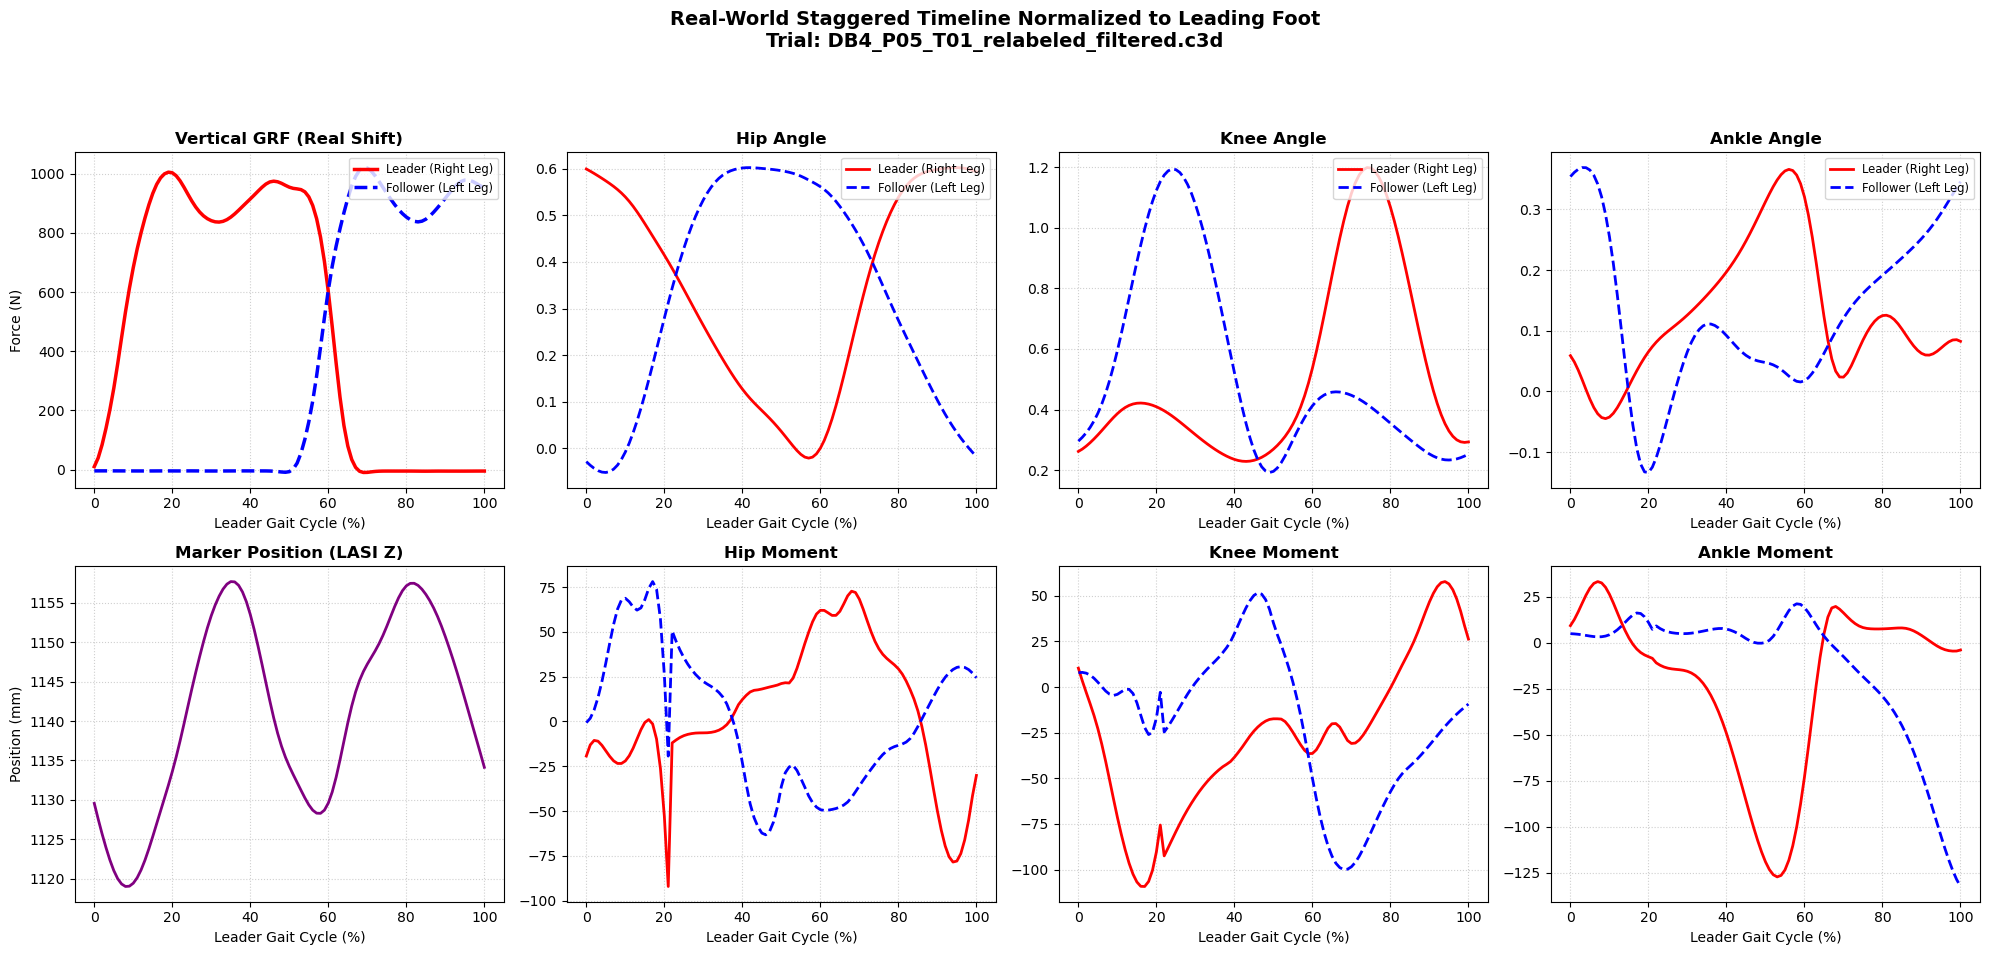

In [26]:
sample_idx = 0
sample_file = c3d_files[sample_idx] 

data = time_normalized_data[sample_file]
normalized_time = np.linspace(0, 100, 101)

ik_headers = pd.read_csv(os.path.join(ik_folder, ik_files[sample_idx]), sep='\t', skiprows=10).columns.tolist()
id_headers = pd.read_csv(os.path.join(id_folder, id_files[sample_idx]), sep='\t', skiprows=10).columns.tolist()

df_c3d = ezc3d.c3d(os.path.join(c3d_folder, sample_file))
c3d_labels = df_c3d['parameters']['POINT']['LABELS']['value']
lasi_m_idx = c3d_labels.index('LASI') if 'LASI' in c3d_labels else 0

# --- PLOT SETUP ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
joints = ['hip_flexion', 'knee_angle', 'ankle_angle']
titles = ['Vertical GRF (Real Shift)', 'Hip Angle', 'Knee Angle', 'Ankle Angle', 
          'Marker Position (LASI Z)', 'Hip Moment', 'Knee Moment', 'Ankle Moment']

# Decode side indexes (0 = Left -> Blue, 1 = Right -> Red)
f1_side, f2_side = data['side_labels']
f1_color = 'blue' if f1_side == 0 else 'red'
f2_color = 'blue' if f2_side == 0 else 'red'

# Dynamically construct labels for the legend
f1_anatomy_str = "Left" if f1_side == 0 else "Right"
f2_anatomy_str = "Left" if f2_side == 0 else "Right"

f1_label_str = f"Leader ({f1_anatomy_str} Leg)"
f2_label_str = f"Follower ({f2_anatomy_str} Leg)"

# 1. Plot Vertical GRF (Index 2) showcasing the real-world shift and colors
axes[0, 0].plot(normalized_time, data['GRF_f1'][2, :], color=f1_color, linewidth=2.5, label=f1_label_str)
axes[0, 0].plot(normalized_time, data['GRF_f2'][2, :], color=f2_color, linewidth=2.5, linestyle='--', label=f2_label_str)

# 2. Plot LASI Marker position
axes[1, 0].plot(normalized_time, data['kinematics'][2, lasi_m_idx, :], color='purple', linewidth=2)

# 3. Plot Joint Angles and Moments for BOTH sides simultaneously
for j_idx, joint in enumerate(joints):
    # Leader columns
    f1_ik_c = get_col_idx(ik_headers, joint, f1_side)
    f1_id_c = get_col_idx(id_headers, joint, f1_side)
    # Follower columns
    f2_ik_c = get_col_idx(ik_headers, joint, f2_side)
    f2_id_c = get_col_idx(id_headers, joint, f2_side)

    # Angles (Row 0)
    axes[0, j_idx + 1].plot(normalized_time, data['ik'][f1_ik_c, :], color=f1_color, linewidth=2, label=f1_label_str)
    axes[0, j_idx + 1].plot(normalized_time, data['ik'][f2_ik_c, :], color=f2_color, linewidth=2, linestyle='--', label=f2_label_str)
    
    # Moments (Row 1)
    axes[1, j_idx + 1].plot(normalized_time, data['id'][f1_id_c, :], color=f1_color, linewidth=2)
    axes[1, j_idx + 1].plot(normalized_time, data['id'][f2_id_c, :], color=f2_color, linewidth=2, linestyle='--')

# Layout Adjustments & Legend Filtering
for i, ax in enumerate(axes.flat):
    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.set_xlabel("Leader Gait Cycle (%)")
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Only append a clean local legend to the multi-line subplots to keep it neat
    if i in [0, 1, 2, 3]:
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize='small')

# Add specific axis metrics
axes[0, 0].set_ylabel("Force (N)")
axes[1, 0].set_ylabel("Position (mm)")

fig.suptitle(f"Real-World Staggered Timeline Normalized to Leading Foot\nTrial: {sample_file}", 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

In [27]:
## STRUCTURE INSPECTION BLOCK
print("=== Checking time_normalized_data Structure ===\n")
print(f"Total Trials Cached: {len(time_normalized_data)}")
print(f"Dictionary Type: {type(time_normalized_data)}\n")

# Pick the first available trial to inspect its contents
first_trial_key = list(time_normalized_data.keys())[0]
trial_content = time_normalized_data[first_trial_key]

print(f"Sample Key (Trial File): {first_trial_key}")
print(f"Internal Data Type: {type(trial_content)}")
print("-" * 60)

for key, value in trial_content.items():
    if isinstance(value, np.ndarray):
        print(f"🔑 Key: '{key:<15}' | Type: NumPy Array | Shape: {str(value.shape):<15} | Data Type: {value.dtype}")
    elif isinstance(value, list) and all(isinstance(x, str) for x in value):
        print(f"🔑 Key: '{key:<15}' | Type: Label List  | Length: {len(value):<14} | Preview: {value[:3]}...")
    else:
        print(f"🔑 Key: '{key:<15}' | Type: {type(value).__name__:<11} | Value/Length: {value}")
print("-" * 60)

=== Checking time_normalized_data Structure ===

Total Trials Cached: 3
Dictionary Type: <class 'dict'>

Sample Key (Trial File): DB4_P05_T01_relabeled_filtered.c3d
Internal Data Type: <class 'dict'>
------------------------------------------------------------
🔑 Key: 'kinematics     ' | Type: NumPy Array | Shape: (3, 99, 101)    | Data Type: float64
🔑 Key: 'ik             ' | Type: NumPy Array | Shape: (38, 101)       | Data Type: float64
🔑 Key: 'id             ' | Type: NumPy Array | Shape: (38, 101)       | Data Type: float64
🔑 Key: 'GRF_f1         ' | Type: NumPy Array | Shape: (6, 101)        | Data Type: float64
🔑 Key: 'GRF_f2         ' | Type: NumPy Array | Shape: (6, 101)        | Data Type: float64
🔑 Key: 'side_labels    ' | Type: list        | Value/Length: [1, 0]
🔑 Key: 'marker_labels  ' | Type: Label List  | Length: 99             | Preview: ['QTMMod_head_top', 'LFHD', 'RFHD']...
🔑 Key: 'grf_labels     ' | Type: Label List  | Length: 6              | Preview: ['Fx', 'Fy', 'F

### PENDIENTE: 
1. Renombrar _1 y _2 para leader y follower
2. Make global C.S. with ankl_1
3. Export to CSV (revisar orden de datos)

### Labels renaming, Dimensionality flattening and global C.S. wrt ANKL_1

In [28]:
def rename_label_string(label, lead_char, foll_char, is_marker=False, axis_str=""):
    """
    Renames a single label string based on leading/following characteristics.
    Handles C3D markers (prefixes) and OpenSim variables containing side characters.
    """
    if is_marker:
        # Case A: Leading foot marker (e.g., 'RTHI' -> 'THI_x1')
        if label.startswith(lead_char):
            return f"{label[1:]}_{axis_str}1"
        # Case B: Following foot marker (e.g., 'LTHI' -> 'THI_x2')
        elif label.startswith(foll_char):
            return f"{label[1:]}_{axis_str}2"
        # Case C: Neutral markers (e.g., 'SACRAL' -> 'SACRAL_x')
        else:
            return f"{label}_{axis_str}"
    else:
        # Define lowercase search tags
        lead_tag = f"_{lead_char.lower()}"
        foll_tag = f"_{foll_char.lower()}"
        
        # Case A: Label belongs to the leading side
        if lead_tag in label:
            # Strip the side tag out of the string wherever it lives, then add '_1' to the end
            cleaned_name = label.replace(lead_tag, "")
            return f"{cleaned_name}_1"
            
        # Case B: Label belongs to the following side
        elif foll_tag in label:
            # Strip the side tag out of the string wherever it lives, then add '_2' to the end
            cleaned_name = label.replace(foll_tag, "")
            return f"{cleaned_name}_2"
            
        # Case C: Neutral joint degrees/coordinates (e.g., 'pelvis_tilt')
        else:
            return label

In [29]:
# New
## MAIN PROCESSING STREAM: Relabeling, Flattening, & Spatial Origin Translation
standardized_time_data = {}
axes_chars = ['x', 'y', 'z']
grf_components = ['Fx', 'Fy', 'Fz', 'Mx', 'My', 'Mz']

for c3d_name, trial_data in time_normalized_data.items():
    # Identify anatomical side characters based on saved side labels (0=Left, 1=Right)
    f1_side_idx, _ = trial_data['side_labels']
    lead_char = 'L' if f1_side_idx == 0 else 'R'
    foll_char = 'R' if f1_side_idx == 0 else 'L'
    
    trial_output = {}

    # ----------------------------------------------------
    # 1. KINEMATICS: Flatten (3, M, 101) to (3*M, 101) & Relabel
    # ----------------------------------------------------
    flat_kinematics = []
    new_marker_labels = []
    
    num_markers_in_matrix = trial_data['kinematics'].shape[1]
    original_labels = trial_data['marker_labels']

    for ax_idx, ax_str in enumerate(axes_chars):
        for m_idx in range(num_markers_in_matrix):
            # Safeguard: Verify the matrix index doesn't overshoot our label reference array
            if m_idx < len(original_labels):
                label = original_labels[m_idx]
                renamed = rename_label_string(label, lead_char, foll_char, is_marker=True, axis_str=ax_str)
            else:
                renamed = f"UnlabelledPoint{m_idx}_{ax_str}"
                
            new_marker_labels.append(renamed)
            flat_kinematics.append(trial_data['kinematics'][ax_idx, m_idx, :])

    # Convert to a modifiable NumPy array of shape (Num_Features, 101)
    kinematics_matrix = np.array(flat_kinematics)

    # ----------------------------------------------------
    # NEW STEP: Spatial Origin Translation (Relative to ANKL_1 at Frame 0)
    # ----------------------------------------------------
    # Find the row indices for the leading ankle's x, y, and z coordinates
    try:
        ankl_x1_idx = new_marker_labels.index("ANK_x1")
        ankl_y1_idx = new_marker_labels.index("ANK_y1")
        ankl_z1_idx = new_marker_labels.index("ANK_z1")
        
        # Capture the origin translation offset vector at frame 0
        origin_x_offset = kinematics_matrix[ankl_x1_idx, 0]
        origin_y_offset = kinematics_matrix[ankl_y1_idx, 0]
        origin_z_offset = kinematics_matrix[ankl_z1_idx, 0]
        
        # Apply the subtraction to all rows belonging to the respective axes across all 101 points
        num_features = len(new_marker_labels)
        markers_per_axis = num_features // 3  # Because we unrolled X, then Y, then Z evenly
        
        # Subtract X offset from the first third of rows
        kinematics_matrix[0 : markers_per_axis, :] -= origin_x_offset
        
        # Subtract Y offset from the middle third of rows
        kinematics_matrix[markers_per_axis : 2 * markers_per_axis, :] -= origin_y_offset
        
        # Subtract Z offset from the final third of rows
        kinematics_matrix[2 * markers_per_axis : num_features, :] -= origin_z_offset
        
    except ValueError:
        print(f"⚠️ Warning: Could not find 'ANKL_1' markers in {c3d_name}. Skipping spatial translation for this trial.")

    # Store the spatially corrected matrix and labels
    trial_output['kinematics'] = kinematics_matrix
    trial_output['kinematics_labels'] = new_marker_labels

    # ----------------------------------------------------
    # 2. GRF: Dynamic Hardware Assignment & Relabeling
    # ----------------------------------------------------
    trial_output['GRF_f1'] = trial_data['GRF_f1']
    trial_output['GRF_f1_labels'] = [f"{comp}1" for comp in grf_components]
    
    trial_output['GRF_f2'] = trial_data['GRF_f2']
    trial_output['GRF_f2_labels'] = [f"{comp}2" for comp in grf_components]

    # ----------------------------------------------------
    # 3. OPEN SIM CHANNELS: IK & ID Relabeling
    # ----------------------------------------------------
    for stream in ['ik', 'id']:
        new_labels = [
            rename_label_string(lbl, lead_char, foll_char, is_marker=False)
            for lbl in trial_data[f'{stream}_labels']
        ]
        trial_output[stream] = trial_data[stream]
        trial_output[f'{stream}_labels'] = new_labels

    # Maintain structural side trackers as metadata
    trial_output['side_labels'] = trial_data['side_labels']
    
    # Save processed dataset
    standardized_time_data[c3d_name] = trial_output

print(f"✅ Processed, flattened, and spatially zeroed {len(standardized_time_data)} trial files successfully!")

✅ Processed, flattened, and spatially zeroed 3 trial files successfully!


In [30]:
## POST-RELABEL VERIFICATION PRINTER
sample_key = list(standardized_time_data.keys())[0]
sample_out = standardized_time_data[sample_key]

print(f"Inspecting Cleaned Output for Trial: {sample_key}\n")
print(f"Leader Side Context: {'LEFT' if sample_out['side_labels'][0] == 0 else 'RIGHT'}\n")

# Spot-check a subset of the output profiles
print(f"Flattened Kinematics Matrix Shape : {sample_out['kinematics'].shape}")
print(f"Sample Flattened Marker Labels     : {sample_out['kinematics_labels'][:4]} ... {sample_out['kinematics_labels'][-3:]}")
print("-" * 80)
print(f"Sample GRF Foot 1 Labels          : {sample_out['GRF_f1_labels']}")
print(f"Sample GRF Foot 2 Labels          : {sample_out['GRF_f2_labels']}")
print("-" * 80)
print(f"Sample Joint Angle (IK) Labels    : {sample_out['ik_labels'][11:15]}")
print(f"Sample Joint Moment (ID) Labels   : {sample_out['id_labels'][11:15]}")

Inspecting Cleaned Output for Trial: DB4_P05_T01_relabeled_filtered.c3d

Leader Side Context: RIGHT

Flattened Kinematics Matrix Shape : (297, 101)
Sample Flattened Marker Labels     : ['QTMMod_head_top_x', 'FHD_x2', 'FHD_x1', 'BHD_x1'] ... ['QTMMod_head_l_z', 'QTMMod_head_r_z', 'QTMMod_head_front_z']
--------------------------------------------------------------------------------
Sample GRF Foot 1 Labels          : ['Fx1', 'Fy1', 'Fz1', 'Mx1', 'My1', 'Mz1']
Sample GRF Foot 2 Labels          : ['Fx2', 'Fy2', 'Fz2', 'Mx2', 'My2', 'Mz2']
--------------------------------------------------------------------------------
Sample Joint Angle (IK) Labels    : ['ankle_angle_1', 'subtalar_angle_1', 'mtp_angle_1', 'hip_flexion_2']
Sample Joint Moment (ID) Labels   : ['ankle_angle_moment_1', 'subtalar_angle_moment_1', 'mtp_angle_moment_1', 'hip_flexion_moment_2']


In [31]:
# Quick test print to verify the zeroing works
sample_out = standardized_time_data[list(standardized_time_data.keys())[0]]
lbls = sample_out['kinematics_labels']
mat = sample_out['kinematics']

x_idx, y_idx, z_idx = lbls.index("ANK_x1"), lbls.index("ANK_y1"), lbls.index("ANK_z1")
print(f"ANKL_1 Coordinates at Frame 0 -> X: {mat[x_idx, 0]:.1f}, Y: {mat[y_idx, 0]:.1f}, Z: {mat[z_idx, 0]:.1f}")

ANKL_1 Coordinates at Frame 0 -> X: 0.0, Y: 0.0, Z: 0.0


### Export data to CSV

In [32]:
output_dir = f'../prep_data/{database}/{participant}'
os.makedirs(output_dir, exist_ok=True)   # If it doesn't exist, create it

print(f"🚀 Starting CSV export pipeline to target directory:\n👉 {output_dir}\n")

# --- MAIN EXPORT LOOP ---
for c3d_name, trial_data in standardized_time_data.items():
    
    # 1. Combine all the processed label lists in your exact requested order
    combined_headers = (
        trial_data['kinematics_labels'] + 
        trial_data['GRF_f1_labels'] + 
        trial_data['GRF_f2_labels'] + 
        trial_data['ik_labels'] + 
        trial_data['id_labels']
    )
    
    # 2. Extract the corresponding data matrices
    # Each array is structured as (Number of Features x 101 frames)
    kin_mat = trial_data['kinematics']
    f1_mat  = trial_data['GRF_f1']
    f2_mat  = trial_data['GRF_f2']
    ik_mat  = trial_data['ik']
    id_mat  = trial_data['id']
    
    # 3. Horizontally stack along axis 0 (the feature axis)
    # This aligns all columns together while keeping the 101 frames running vertically down
    stacked_features_matrix = np.vstack([kin_mat, f1_mat, f2_mat, ik_mat, id_mat])
    
    # 4. Transpose the matrix so Rows = Frames (0 to 100), Columns = Ordered Features
    final_csv_grid = stacked_features_matrix.T
    
    # 5. Convert to a Pandas DataFrame to assign the headers seamlessly
    df_export = pd.DataFrame(final_csv_grid, columns=combined_headers)
    
    # Optional: Add an explicit Gait_Cycle_Pct index column (0 to 100) at the start
    df_export.insert(0, 'Gait_Cycle_Pct', np.arange(101))
    
    # 6. Generate the clean export file name (swapping .c3d extension for .csv)
    csv_file_name = os.path.splitext(c3d_name)[0] + '.csv'
    export_path = os.path.join(output_dir, csv_file_name)
    
    # 7. Write out to disk (index=False ensures the DataFrame's numeric tracking index is hidden)
    df_export.to_csv(export_path, index=False)
    
    print(f"  ↳ 💾 Exported: {csv_file_name} | Grid Dimensions: {df_export.shape[0]} rows x {df_export.shape[1]} cols")

print(f"\n============================================================")
print(f"✅ Success! All processed trials are cleanly written to disk.")
print(f"============================================================")

🚀 Starting CSV export pipeline to target directory:
👉 ../prep_data/DB4/P05

  ↳ 💾 Exported: DB4_P05_T01_relabeled_filtered.csv | Grid Dimensions: 101 rows x 386 cols
  ↳ 💾 Exported: DB4_P05_T02_relabeled_filtered.csv | Grid Dimensions: 101 rows x 386 cols
  ↳ 💾 Exported: DB4_P05_T04_relabeled_filtered.csv | Grid Dimensions: 101 rows x 386 cols

✅ Success! All processed trials are cleanly written to disk.


### What about the other data in Sophie's CSV ?